# **랭그래프**(**LangGraph**)

## 1. 랭그래프란(LangGraph)

- **LangGraph**는 LangChain 생태계에서 개발된 **그래프구조 기반 워크플로우 및 에이전트 개발을 위한 런타임 프레임워크**이다.
- LangGraph는 선형적 흐름이 아닌 **비선형적인 복잡한 흐름 구조의 AI 에이전트 애플리케이션을 견고하고 재현 가능하게**(**build reliable**) 구성할 수 있도록 설계되었다.
- LangGraph의 가장 큰 특징은 **사이클**(**순환 구조**)을 지원한다는 점이다. 이는 특정 조건에 따라 이전 단계로 돌아가거나 다른 경로를 선택할 수 있음을 의미한다.   
예를 들어, 검색 결과가 만족스럽지 않을 때 다시 검색을 수행하거나, 답변의 품질이 낮을 때 재생성을 요청하는 등의 복잡한 로직을 구현할 수 있다.
+ LCEL에서는 구현 불가한 거(만족스럽지 않을 때 돌아가기, 순환 불가) -> 조금 나은 게 병렬처리 -> 랭그래프(langchain의 확장) 

> **그래프**(**Graph**) **구조**
> - 데이터를 저장하고 조직화하는 자료구조 중 하나로 **데이터 간의 관계를 중심으로 정보를 표현하는 방식**의 자료구조다.
> - 데이터를 나타내는 **Node**(**노드**)와 Node와 Node를 연결하여 관계를 나타내는 **Edge**(**엣지**)로 데이터간의 구조를 표현한다.
>     - LangGraph는 **Node가 '작업(Task)'을 수행(단계적인 일을 처리해주는 연산식)하고, Edge가 '작업의 흐름'**(**Control Flow**)을 정의한다.
>
> **런타임 프레임워크**(**Runtime Framework**)    
> - 애플리케이션이 실행되는 동안(Runtime)에 필요한 기능과 실행 환경을 제공하는 프레임워크를 말한다.(만든 프레임워크를 특정 시점에 실행까지 해줌)
> - 즉 프로그램이 동작하는 동안 필요한 공통 기능을 대신 처리해 주는 프레임워크이다.

## 2. LangGraph 핵심개념

- **그래프 기반 실행**: 애플리케이션의 실행 흐름을 '**노드**(**node**)와 **엣지**(**edge**)'로 구성된 그래프로 표현하여 분기, 병렬, 반복 구조를 자연스럽게 다룸.
- **상태 유지(stateful):** 실행 중인 에이전트의 상태(context)를 런타임이 관리하며 중단/재개 시에도 상태가 유지되도록 한다.
- **장기 실행(durable workflows):** 서버 재시작, 장시간 실행 등 프로덕션 조건에서도 상태를 유지하며 워크플로우를 이어갈 수 있는 기능 포함하고 있다.
- **멀티 에이전트 및 상호작용:** 여러 AI 에이전트가 협력하여 복잡한 작업을 수행할 수 있는 환경을 제공한다.
- state 공유장소: 작업 결과를 공유 장소에 저장해두고(모든 노드들이 공유할 수 있는 작업 공간-데이터를 만들어두고), 갖다 쓰고 함 => '상태 유지' (중간에 끊겨도 공유 장소 내 데이터가 사라지지 X. 하나의 작업이 완전히 끝날 때까지)

## 3. 랭체인(LangChain)과의 관계

- **LangGraph는 LangChain의 기능을 확장하여 만들어진 프레임워크이다.** 
  - LangGraph는 LangChain에서 제공하는 여러 구성 요소(모델 호출, 도구 등)를 **low level에서 제어**할 수 있게 확장한 프레임워크이다.
    - LangGraph는 개발자가 모델 호출과 도구 실행 등의 순서, 조건에 따른 분기등을 직접 구성할 수 있다.
  - 필요 시 LangChain 에이전트를 LangGraph 워크플로우내의 Node로 사용할 수 있는 **상호 보완적 관계**이다.


### 비교

| 비교 항목            | **LangChain**                        | **LangGraph**                            |  
| ------------------ | ------------------------------------- | --------------------------------------- | 
| 실행 흐름            | **선형/순차 중심** 워크플로우         | **그래프 기반** 복잡한 흐름 (분기·루프·상태 흐름)  |
| 상태 관리            | 기본 메모리/세션 중심                 | **지속 상태(durable)**, 런타임 저장·복원        |
| 추상화 수준          | `LCEL`을 이용한**고수준(high-level)** API | **저수준(low-level)** 실행 제어           | 
| 적합한 용도          | 간단한 에이전트 & 워크플로우          | 복잡한 실행흐름의 멀티 에이전트, 상태 기반 시스템 등 |



# 랭그래프 기본 구조

## 1. 노드(Node) 와 엣지(Edge)

랭그래프의 기본 구조는 **노드**(**Node)** 와 **엣지**(**Edge**)로 구성된다.

### **노드**(**Node**): 
- 그래프 상의 처리 단위
- 실제 작업을 수행하는 'Python 함수'들로, 각각의 노드는 '특정 로직'을 담당한다. 
- 노드는 현재 '상태를 입력'으로 받아서 작업을 수행하고, 업데이트된 '상태를 반환'한다.
- 예를 들어, LLM 호출, 문서 검색, 데이터 처리 등의 기능을 수행할 수 있다.
- **특수노드**
  - `START`(생략 불가)
    - Graph의 시작점(Entry Point)를 나타내는 특수 노드. 
    - `langgraph.graph.START` 상수를 이용해 지정한다. 
  - `END`(넣는 게 좋지만 생략 가능)
    - Graph의 종료점(Terminal Point)를 나타내는 특수 노드. 
    - `langgraph.graph.END` 상수를 이용해 지정한다.
  - `START`, `END` 는 일반 노드와 다르게 
    - 실행함수가 없다.
    - State(상태)를 처리하지 않는다.
    - add_node()로 Graph에 등록하지 않는다.
    - 단지 그래프의 시작과 끝을 나타내기 위한 예약된 상수이다.
  
### **엣지**(**Edge**):
-  노드 간의 연결을 정의하며, 다음에 어떤 노드를 실행할지 결정하는 역할을 한다. 
-  엣지는 워크플로우의 **흐름을 제어**하고 조건부 라우팅을 통해 **분기, 반복**을 가능하게 한다.

## 2. 상태(State)

- 상태(State)는 'Graph가 실행되는 동안 유지'되는 '값들의 저장소/메모리' 이다.
- 에이전트 실행 중 모든 노드가 이 상태에 '접근하여 값들을 조회'할 수 있으며, 각 노드들은 '작업 결과를 State에 업데이트'할 수 있다. 
- 상태(State)는 에이전트 실행중에 key-value 형태로 관리되는 Dictionary 이다. State Schema(상태 구조/설계도) 를 먼저 정의하고 그것을 Graph 생성시 전달한다. 
  - State Schema는 State의 Field(속성, 구성요소)들을 정의한 것이다.
  - State schema에 정의된 key의 Field들만 State에 저장되어 관리된다.
  - State Schema는 **TypedDict 또는 pydantic.BaseModel을 상속한 클래스로 정의**한다.
  - 노드들은 State Schema에 정의된 Field들만 상태로 저장할 수 있다.

- **상태(State)의 주요 역할**
    - **전체 워크플로우의 '컨텍스트 유지**'
        -  에이전트가 여러 단계를 실행하는 동안 처리 과정에서 필요한 모든 정보를 한 곳(상태-dict)에서 관리한다
    - '**노드 간 정보 공유**'
        -  한 노드의 실행 결과를 state 필드에 저장하고, 다른 노드가 이를 조회해 사용한다. 이를 통해 노드들이 데이터를 공유할 수 있다.
    - '**진행 상황 추적**'
        -  에이전트가 현재 실행 중이거나 다음에 실행될 노드가 무엇인지, 이미 완료된 태스크는 무엇인지, 그리고 사용자 승인(HITL) 같은 의사결정 정보까지 state의 필드로 기록할 수 있다. 
        -  이 정보들을 기반으로 그래프 실행 흐름을 조율하고, 조건 분기나 다음 단계 실행을 관리·추적할 수 있게 한다.


## 3. StateGraph

- StateGraph는 LangGraph의 핵심 클래스로, 상태(State)를 기반으로 동작하는 그래프를 정의하는 역할을 한다.
- StateGraph는 그래프에서 사용할 상태(State)의 구조(Schema)와 상태 업데이트 규칙을 정의한다.
- 그래프 실행 중에는 현재 상태가 모든 노드 사이에서 공유되도록 하며, 각 노드가 반환한 값은 StateGraph가 정의한 규칙에 따라 기존 상태와 병합되어 다음 노드로 전달된다.
- StateGraph를 생성할 때 상태 스키마를 지정하며, 각 노드(Node)는 상태를 dict로 받아서 사용할 수 있고 실행 결과를 dict 형태로 반환하여 상태를 갱신한다.

## 4. 랭그래프에서 상태관리

랭그래프에서 상태 관리는 두 가지 방식으로 이루어진다:

1. **완전 재정의 방식**:
   - 기본적으로 상태 필드(State Field)는 노드가 반환한 값으로 기존 값을 대체한다.
   - 동일한 필드에 새로운 값이 반환되면 이전 값은 사라지고 새로운 값이 저장된다.
     - key가 같으면 동일한 Field이다.
2. **업데이트 방식**: 
   - **Reducer**(정해주는 함수)를 이용한다.
   - '리'스트'와 같이 '기존 값을 유지'하면서 '새로운 값을 추가'해야 하는 경우 'Reducer'를 사용할 수 있다.
   - **Reducer**는 기존 상태 값과 노드가 반환한 값을 병합하는 규칙을 정의한다. (병합 처리하는 함수이다.)
   - 대표적으로 채팅 메시지를 누적하기 위해 add_messages Reducer를 사용한다.

# 랭그래프 구현

- **설치**
  - `pip install langgraph`
  
## 1. 상태(State) 구조(schema) 정의

- 랭그래프를 구현하기 위해서는 먼저 State 클래스를 정의 한다.
  - State는 `TypedDict`, `pydantic.BaseModel`를 상속받아 정의한다.
    > **TypeDict**: Dictionary Type hint를 위한 클래스로 key와 value의 타입을 정의한다.

  - class 변수로 Field들을 정의 한다.
    - type hint를 이용해 각 Field(key)가 어떤 타입의 값을 가질 지 선언한다. 
    - 리스트 병합 같은 결합 규칙이 필요한 필드는 `Annotated[..., reducer]` 형태로 reducer 함수를 지정한다.
    - Reducer는 field가 가진 기존 값에 노드가 추가한 새 값을 어떻게 결합할지 정의한다 (예: 리스트 추가, 값 덮어쓰기, 사용자 정의 병합 등)
  - State 클래스는 그래프 실행 전반에서 Node들이 공유/업데이트하는 상태 데이터의 스키마이며, 실제 실행 시 상태는 **Dictionary 인스턴스**로 관리된다.

    ```python
      from typing import TypedDict
      class MyState(TypedDict):
          counter: int
          messages: list 
    ```


## 2. 노드(Node) 정의

- 노드는 실제 작업을 수행하는 Python 함수로 정의된다.  
- 각 노드 함수는 **현재 상태**를 입력으로 받아 처리 후 **업데이트된 상태**를 반환한다.
  - 처리결과를 State에 추가 한 것
  - 추가할 것이 없을 경우 None을 반환한다.

  ```python
  def increment_counter(state):    
      return {"counter": state["counter"] + 1} 
      
  def process_message(state):
      # 메시지 처리 로직    
      new_message = "처리된 메시지"    
      return {"messages": state["messages"] + [new_message]}
  ```


## 3. 엣지(Edge) 정의

- 엣지는 노드 간의 연결을 정의하며, `StateGraph`에 `add_edge()` 메서드를 사용하여 추가한다. 기본적인 엣지는 한 노드에서 다른 노드로의 단방향 연결 흐름을 의미한다.

  ```python
  graph.add_edge("node1", "node2") 
  graph.add_edge("node2", "node3")
  ```

## 4. 상태그래프(StateGraph) 구성

- 노드와 엣지를 정의한 후에는 그래프를 구성하고 컴파일해야 한다. 
  - `StateGraph`를 생성하고 그래프에 노드들을 추가한다.
  - 각 노드들을 연결하여 엣지를 추가한다. 이 과정에서 시작점과 종료점을 설정한다.
  - 컴파일을 통해 그래프의 구조를 검증하고 실행가능한 상태로 만든다.

    ```python
    from langgraph.graph import START, END
    from langgraph.graph import StateGraph 

    # StateGraph 생성
    graph = StateGraph(MyState)

    # 노드 추가 
    graph.add_node("increment", increment_counter) 
    graph.add_node("process", process_message) 
    # 엣지 추가 
    graph.add_edge(START, "increment") 
    graph.add_edge("increment", "process") 
    graph.add_edge("process", END) 
    # 그래프 컴파일 
    app = graph.compile(
    ```


## 5. 호출(상태 그래프 실행)

- `invoke()` 와 `stream()` 을 이용해 호출한다.
  - 메소드 호출시 **초기 상태(Initial state)를 제공**하여 그래프를 실행한다. 
    - 그래프는 이 초기 상태부터 시작하여 정의된 노드들을 순차적으로 실행하며 상태를 업데이트한다.
  - **checkpointer 저장소(메모리)를 사용**할 경우 **thread-id를 RunnableConfig로 전달**한다.
    - **thread_id**는 LangGraph에서 **하나의 workflow(그래프) 실행 세션을 식별하기 위한 ID** 
    - 개별 실행(invoke()/stream() 호출)이 아닌 **전체 작업시작 ~ 종료**까지의 논리적 단위를 식별하는 ID이다. 
      - 챗봇으로 보자면 챗봇창을 시작해서 대화가 끝나고 챗봇창을 닫을 때 까지의 단위이다.
- **invoke(input, config)**
  - 그래프(워크플로우)를 한 번 실행하고 최종 State 결과만 반환한다.
    ```python
    result = app.invoke({"counter": 0, "messages": []}) 
    print(result)
    ```
- **stream(input, config)**
  - 그래프 실행 중 발생하는 이벤트를 실시간으로 yield(스트리밍)하여 반환한다. 이벤트는 보통 각 node(task) 종료를 말한다.
  - **stream_mode** 설정에 따라 yield 되는 값이 다르다.
    - `"values"`: 각 노드가 끝나는 시점의 **전체 State 상태**(State Snapshot이라고한다.)를 반환.
    - `"updates"`: 각 노드가 반환한 상태 값만 반환. `{"node이름": {key:value, ..}}`
    - `"messages"`: Node가 출력한 대화 메세지(Agent/LLM 이 출력한)만 반환.

    ```python
      for event in app.stream({"counter": 0, "messages": []}) 
          print(event)
    ```

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict 

In [53]:
# 1. State Schema 설계 -> State에 어떤 값들(Field) 저장할 수 있는지 설계
class State(TypedDict): # State(dict)를 만드는 것이 아닌, 설계하는 것(State는 LangGraph 실행 환경이 만드는 것)
    save_path: str # key-value의 타입(지정되지 않은 값은 저장 안 됨)
    name: str
    age: int
    address: str
    result: str

In [60]:
# 2. Node 구현(Node가 호출할 함수) -> 함수로 구현 - 파라미터 : state(dict)를 받는 변수, 반환값(return): dict - {key: value}: State에 저장할 Field
def add_name(state:State):
    print("------add_name 노드 실행------", type(state))
    print("add_name에서 state 값: ", state)
    return {"name": "이순신", "name2": "유관순", "name3": "강감찬"} # State에 "name-이순신"이 추가
    # name(스키마에 있는 key(필드 이름)), name2, name3은 스키마에 없는 key

def add_age(state:State):
    print("------add_age 노드 실행------")
    print("add_age에서 State 값: ", state)
    return {"age": 30}

def add_address(state:State):
    print("------add_address 노드 실행------")
    print("add_address에서 State 값: ", state)
    return {"address": "서울시 금천구 독산동"}

def save_info(state: State):
    """add_xxx 노드들이 만든 값을 save_path에 저장"""
    # state에서 필요한 정보들 조회
    try:
        save_path = state['save_path']
        name = state['name']
        age = state['age']
        address = state['address'] # state.get('address')
        print(f"{save_path}에 {name}, {age}, {address}을/를 저장합니다.")
        # State에 추가할 값이 없으면 return None
    except:
        return {"result": "Fail"} # result를 schema에 추가

In [61]:
# 3. StateGraph 생성 후 StateGraph에 Node와 Edge 정의
workflow = StateGraph(State) #State Schema를 넣고 생성

# None 추가 - 노드이름, 함수 정의
workflow.add_node("add_name", add_name)
workflow.add_node("add_age", add_age)
workflow.add_node("add_address", add_address)
workflow.add_node("save_info", save_info)

# Edge 설정 = Node와 Node의 흐름
# START -> add_name -> add_age -> add_address -> END
workflow.add_edge(START, "add_name") # 출발지 노드 -> 다음 노드
workflow.add_edge("add_name", "add_age")
workflow.add_edge("add_age", "add_address")
workflow.add_edge("add_address", "save_info")
workflow.add_edge("save_info", END)

# StateGraph 컴파일: 그래프 구성 검증, 최적화 => 실행 가능한 상태로 만드는 작업
graph = workflow.compile()

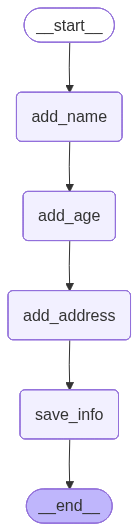

In [62]:
# Graph의 구조 시각화
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [63]:
# 호출
# res = graph.invoke({})
res = graph.invoke({"save_path":r"c:\src"}) # : State에 저장할 값을 dict로 전달
# 반환값(res): State dictionary

------add_name 노드 실행------ <class 'dict'>
add_name에서 state 값:  {'save_path': 'c:\\src'}
------add_age 노드 실행------
add_age에서 State 값:  {'save_path': 'c:\\src', 'name': '이순신'}
------add_address 노드 실행------
add_address에서 State 값:  {'save_path': 'c:\\src', 'name': '이순신', 'age': 30}
c:\src에 이순신, 30, 서울시 금천구 독산동을/를 저장합니다.


In [64]:
res

{'save_path': 'c:\\src', 'name': '이순신', 'age': 30, 'address': '서울시 금천구 독산동'}

In [65]:
for event in graph.stream({"save_path":r"c:\src"}, stream_mode="messages"):
    print("Event:", event)
    print("-------------------------------------------------")

# stream({}, stream_mode="모드")
# 모드: updates(기본) -> 각 Node가 끝날 때마다 그 노드가 반환한 State를 반환 {"노드이름": {state}}
#       value -> 각 노드가 종료될 때마다 그 시점의 전체 state 반환
#       messages -> LLM의 응답 chunck(token) 반환(chatbot에서 사용)

------add_name 노드 실행------ <class 'dict'>
add_name에서 state 값:  {'save_path': 'c:\\src'}
------add_age 노드 실행------
add_age에서 State 값:  {'save_path': 'c:\\src', 'name': '이순신'}
------add_address 노드 실행------
add_address에서 State 값:  {'save_path': 'c:\\src', 'name': '이순신', 'age': 30}
c:\src에 이순신, 30, 서울시 금천구 독산동을/를 저장합니다.


# 다양한 엣지

## 1. **기본 엣지**

- 기본 엣지(Normal Edge)는 한 노드에서 다른 노드로의 단방향의 연결흐름을 의미한다. 이는 가장 단순한 형태의 연결로, 이전 노드의 작업이 완료되면 자동으로 다음 노드로 이동한다.
- 기본 엣지는 다음과 같은 특징을 가진다:
  - **고정된 흐름**: 항상 동일한 다음 노드로 이동한다      
  - **단순한 구조**: 복잡한 조건 없이 순차적으로 실행된다      
  - **예측 가능한 동작**: 실행 전에 전체 흐름을 예측할 수 있다    

## 2. **조건부 엣지**

- 조건부 엣지(Conditional Edge)는 특정 **조건에 따라 다음에 실행할 노드를 동적으로 결정**하는 기능이다. 
- 이를 이용해 제어문적 요소 (조건문, 반복문)을 Workflow에 추가할 수 있다. 
- 그래서 순차적 흐름 뿐 아니라 다양한 흐름의 구조를 구현할 수있게 되어 **복잡한 의사결정 로직**을 구현할 수 있다.
- `add_conditional_edges(source_node, 라우팅_함수, path_map)` 을 이용해 정의 한다. 
    1. **소스 노드(Source Node)**
       -  '조건 평가가 시작될 노드'의 이름이다.
       -  이 노드가 생성해서 반환한 상태 값의 조건에 따라 다음 실행할 노드가 결정된다.
    2. **라우팅 함수(Routing Function)**
       - 소스 노드 실행 후의 State 값을 바탕으로 '다음에 실행할 노드를 결정'하는 로직을 포함 제공하는 함수. 
       - **조건에 따라 이동할 다음 노드의 식별값**을 반환한다. (보통 노드 이름을 반환)
    3. **path map - '조건부 엣지 매핑'(Conditional Edge Mapping)**
       -  라우팅 함수가 반환한 식별값에 따라 이동할 노드를 설정한 **딕셔너리 또는 리스트**.
       -  라우팅 함수가 반환한 식별값과 이동할 노드의 이름이 **다른 경우 dict로 정의**한다. `{식별값1:이동할노드이름1, 식별값2: 이동할노드이름2, ..}`
       -  라우팅 함수가 반환한 식별값과 이동할 노드의 이름이 **같은 경우 list로 정의**한다.(딕셔너리로 해도 상관 없음) `[이동할노드이름1, 이동할노드이름2, ...]`
    ```python
      # Source 노드
      def llm_answer(state):
        ...
        return {"relevance_score": score}
      
      # 라우팅 함수
      def relevance_check(state):     
          # 관련성 체크 로직    
          if state["relevance_score"] > 0.8:        
              return "grounded"    
          else:        
              return "not_grounded" 

      # path_map (조건부 엣지 매핑)
      mapping = {        
        "grounded": END,           # 라우팅함수의 반환값이 "grounded" 이면 END 노드로 이동
        "not_grounded": "retrieve" # "not_grounded" 이면 "retrieve" 노드로 이동
      }
      
      # 조건부 엣지 정의       
      graph.add_conditional_edges(
          "llm_answer",     # 소스 노드    
          relevance_check,  # 조건 함수    
          mapping
      )
    ```

## 3. **반복 구조**

- LangGraph 핵심 장점 중 하나는 반복 구조(순환 구조)를 지원한다는 점이다. 
- 반복 구조는 조건이 충족될 때까지 같은 Node들을 여러 번 실행할 수 있게 해준다. 
- 반복 구조의 활용 예시:
  - **검색 품질 개선**
    - 검색 결과가 만족스럽지 않을 때 쿼리를 재작성하여 다시 검색한다.
  - **답변 품질 향상**
    - 생성된 답변의 품질이 낮을 때 다시 생성하거나 개선한다.  
  - **할루시네이션 방지**
    -  답변이 검색된 문서와 관련성이 낮을 때 재생성을 요청한다.
  - **Human In The Loop** 
    - HITL 구조에서 사람의 확인·승인이 완료될 때까지 `멈춤(interrupt) → 사람 입력 → 재개 → 조건 불만족 → 다시 같은 Node로 → 다시 멈춤 → ...` 구조를 반복할 수 있게 한다.
  
## 4. **Command**

- `Command`는 노드의 실행 결과로(노드의 반환값) **상태 업데이트와 다음 이동할 노드 지정을 함께 반환**할 수 있게 해주는 기능이다.(agent-agent 연결)
- 일반적인 조건부 엣지는 `add_conditional_edges()`를 이용해 그래프 외부에서 흐름 제어 로직을 정의한다.
- 반면 `Command`는 **노드 내부에서 다음 이동 경로를 직접 결정**할 수 있다. 그래서 노드가 직접 조건에 따라 어느 경로로 이동할 지 결정할 수 있다.

- `Command`는 다음과 같은 상황에서 유용하다:
  - 노드 실행 결과에 따라 다음 노드를 동적으로 결정해야 할 때
  - 상태 업데이트와 흐름 제어를 한 번에 처리하고 싶을 때
  - 멀티 에이전트 구조에서 특정 에이전트로 작업을 넘겨야 할 때
  - 조건부 엣지보다 노드 내부 로직 중심으로 흐름을 관리하고 싶을 때
  - `Command`를 반환하는 노드함수의 반환 타입에 이동 가능한 노드 이름을 명시하는 type hint를 추가 하는 것이 권장된다.
  
- `Command`의 파라미터:
  1. **update**
     - State에 반영할 값을 dict로 지정한다.
     - 일반 노드에서 `return {"key": value}` 형태로 상태를 업데이트하는 것과 유사하다.
  2. **goto**
     - 다음에 실행할 노드 이름을 지정한다.
     - 라우팅을 Command로 직접 제어할 때 사용하며, **조건부 엣지 없이 동적 라우팅을 할 수 있다**.
     - 보통 처리 결과에 따라 특정 노드로 이동해야 하는 코드를 Node내에 직접 구현할 때 사용한다.
     - Command를 이용한 이동은 **상태 업데이트와 라우팅을 함께 해야 할 때 사용**한다. 만약 **상태 업데이트 없이 라우팅만 필요하면 조건부 엣지를 쓰는 것이 권장**된다.
  3. **graph**
    - `graph`는 `goto`로 지정한 **이동 대상 노드가 현재 graph가 아니라 parent graph에 있을 때** 사용한다.
       - 기본적으로 `goto`는 현재 graph 안의 노드를 대상으로 한다.
       - 하지만 현재 실행 중인 노드가 subgraph 내부에 있고, 이동하려는 노드가 parent graph에 있다면 `graph=Command.PARENT`를 지정한다.
       - 주로 **멀티에이전트 구조**에서 특정 sub agent 내부 노드가 parent graph에 등록된 다른 agent 노드나 supervisor 노드로 handoff할 때 사용한다.
         > - Handoff: 현재 작업을 수행 중인 에이전트가 '다른 에이전트에게 작업의 주도권(Control)을 넘기는 것'을 의미한다.
    
      ```python
        def sub_agent_node(state) -> Command:
          return Command(
              update={"result": "sub agent 작업 결과"},
              goto="parent_agent_node",
              graph=Command.PARENT
          )
      ```
  4. **resume**
    - 'interrupt()로 일시중단'된 그래프를 재개할 때 그래프에 전달할 값지정.
### Command 예
  ```python
  from typing import Literal
  from langgraph.graph import END
  from langgraph.types import Command

  
  #  반환 타입에 이동 가능한 노드 이름을 명시하는 type hint를 추가한다. Command[Literal['이동노드 이름', ...]]
  # `Command[Literal["retrieve", "answer", "__end__"]]`:  이 노드가 `retrieve`, `answer`, `END`로 이동할 수 있음을 나타낸다.
  def router_node(state) -> Command[Literal["retrieve", "answer", "__end__"]]:
      question = state["question"]

      if "검색" in question:
          # 상태를 업데이트 하면서 이동한다.
          return Command(
              update={"route": "retrieve"},
              goto="retrieve"
          )

      elif "답변" in question:
          return Command(
              update={"route": "answer"},
              goto="answer"
          )

      else:
          return Command(
              update={"route": "end"},
              goto=END
          )
  ```
### Conditional Edge(조건부 엣지)와 Command의 차이

| 구분          | Conditional Edge             | Command                           |
| ------------ | ---------------------------- | --------------------------------- |
| 흐름 제어 위치 | 그래프 정의부                   | 노드 내부                          |
| 상태 업데이트  | 노드 반환값에서 처리             | `Command(update=...)`에서 처리     |
| 다음 노드 결정 | 조건 함수가 결정                | 노드가 직접 결정                     |
| 적합한 경우   | 흐름 구조를 명확히 분리하고 싶을 때 | 노드 결과에 따라 즉시 분기하고 싶을 때  |
| 사용 예       | 분류기, 라우터, 반복 조건        | 에이전트 핸드오프, 동적 라우팅, 상태 업데이트 + 이동 |
- Command: 사람의 개입이 필요한 경우, 보통은 조건부 엣지.

## 5. **Send**

- `Send`는 하나의 노드에서 **'여러 개의 작업을 동적으로 생성'하여 '다른 노드로 전달**'할 때 사용하는 기능이다.
- '주로 병렬 처리', map-reduce 패턴, 여러 에이전트에게 작업 분배, 여러 문서나 항목에 대한 반복 처리에 사용된다.
- 일반 엣지나 조건부 엣지는 보통 다음 노드를 **하나만 선택**한다.
- 반면 `Send`는 다음 실행할 노드를 여러 번 호출할 수 있다.
- 각각의 호출에는 서로 다른 State 값을 전달할 수 있다.
- `Send`는 다음과 같은 상황에서 유용하다:

  - 여러 문서를 각각 요약해야 할 때
  - 여러 검색 쿼리를 동시에 처리해야 할 때
  - 여러 에이전트에게 작업을 나누어 맡겨야 할 때
  - 리스트의 각 항목을 개별 노드에서 처리해야 할 때
  - map-reduce 구조를 구현해야 할 때
    > map-reduce란 **큰 작업을 여러 개의 작은 작업으로 분할(Map)하여 병렬 처리한 뒤, 그 결과를 하나로 합치는(Reduce) 처리 방식**을 말한다.

- `Send` 파라미터
  - **node**: 실행할 대상 노드의 이름
  - **arg**
    -  대상 노드에 전달할 입력 state field. 
    -  전체 그래프의 State schema에 없는 Field들을 전달 할 수 있다. 즉 전체 State와 다른 입력 State를 전달할 수 있다. 
  
### Send 사용 예시

```python
from langgraph.types import Send

def send_each_document(state):
    documents = state["documents"]

    return [
        Send("summarize_document", {"document": doc})
        for doc in documents
    ]
```
-  `send_each_document`는 `documents` 리스트를 순회하면서 각 문서를 `summarize_document` 노드로 보낸다.
- 문서가 3개라면 `summarize_document` 노드가 3번 실행된다. 그래서 다음과 같은 효과가 난다.
   ```python
   [
     Send("summarize_document", {"document": doc1}),
     Send("summarize_document", {"document": doc2}),
     Send("summarize_document", {"document": doc3}),
   ]
   ```
- 각 실행에는 서로 다른 `document` 값이 전달된다.

#### 전체 코드(Map-Reducer 구조)

```python
from typing import Annotated, TypedDict
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


class State(TypedDict):
    documents: list[str]
    summaries: Annotated[list[str], operator.add] # 병렬처리되어 반환된 결과들을 모을 Field. 여러 노드 실행 결과가 누적되어야 하므로 Reducer가 필요.
    final_summary: str


# 1. 조건부 엣지가 시작될 source node
def distribute_node(state: State):
    
    # 여기서  파일, DB, 검색 결과 등에서 문서 목록을 가져올 수 있다.

    return {"documents": 조회한 문서 목록(Document List)}


# 2. Send 객체들을 반환하는 routing function
def send_each_document(state: State):
    return [
        Send("summarize_document", {"document": doc}) # Send로 state를 전달 할 때 State Schema에 없는 Field들을 전달 할 수 있다. 
                                                      # (여기서는 `summarize_document`를 호출할 때 전체 state에는 없는 document를 전달하고 있다.) 
        for doc in state["documents"]
    ]


# 3. 각 문서를 개별 요약하는 node
def summarize_document(state):
    document = state["document"]

    summary = llm.invoke(document) # 요약 작업을 LLM에게 요청

    return {"summaries": [summary]}


# 4. 여러 요약 결과를 최종 요약으로 합치는 node
def final_summary(state: State):
    summaries = state["summaries"]

    return {
        "final_summary": "\n".join(summaries)
    }
```

- 그래프 구성

```python
graph = StateGraph(State)

graph.add_node("distribute_node", distribute_node)
graph.add_node("summarize_document", summarize_document)
graph.add_node("final_summary", final_summary)

graph.add_edge(START, "distribute_node")

graph.add_conditional_edges(
    "distribute_node",       # source node 이름
    send_each_document,      # routing function
    ["summarize_document"]   # 가능한 목적지 노드 목록
)

graph.add_edge("summarize_document", "final_summary")
graph.add_edge("final_summary", END)
```

- 이 구조는 다음과 같은 흐름으로 동작한다.

![send](figures/langgraph_send.png)

summarize_document  ← 문서 개수만큼 여러 번 실행 된다.

### Send와 반복 구조의 차이

| 구분    | 반복 구조                | Send               |
| ------- | -------------------- | ------------------ |
| 목적    | 조건이 만족될 때까지 같은 흐름 반복 | 여러 작업을 나누어 실행        |
| 실행 방식 | 순환 구조                         | 분산 실행 / 병렬 처리 구조     |
| 사용 예  | 답변 재생성, 검색 재시도           | 여러 문서 요약, 여러 쿼리 검색 |
| 핵심 개념 | Loop(같은 흐름을 다시(반복)실행)  | Fan-out (하나의 흐름이 여러 갈래로 퍼지는 구조)  |
| 결과 처리 | 상태를 갱신하며 반복              | 여러 결과를 모아 병합          |

* 정리하면, 반복 구조는 **하나의 작업을 조건이 만족될 때까지 다시 실행하는 방식**이다.
* `Send`는 **여러 작업을 동시에 또는 독립적으로 나누어 실행하는 방식**이다.


In [67]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import Annotated
from typing_extensions import TypedDict

from datetime import date

In [ ]:
# name: Annotated[str, "고객의 이름"]

In [84]:
# State Schema 설계
class State(TypedDict):
    messages: Annotated[list, add_messages] # list에 노드가 반환한 리스트의 값들을 append
    # Annotated[타입, 함수(Reducer)]- Reducer: 노드가 반환한 값을 어떻게 State에 저장할 지 결정하는 함수

In [85]:
# add_messages([1, 2, 3], [10, 20]) # => [1, 2, 3, 10, 20]
add_messages([HumanMessage(content="A")], [HumanMessage(content="B")])
# [HumanMessage(content='A', additional_kwargs={}, response_metadata={}, id='4c7641c4-6201-4f8e-bc05-5c4fe57381b5'),
#  HumanMessage(content='B', additional_kwargs={}, response_metadata={}, id='a42f33f7-d09c-45dc-aca2-5835de7f0d44')]
# => left_list + right_list
# = operator.add([1, 2, 3], [10, 20, 30]) => [1, 2, 3, 10, 20, 30]

[HumanMessage(content='A', additional_kwargs={}, response_metadata={}, id='5face110-28ab-41a9-a59a-c281692b8ba1'),
 HumanMessage(content='B', additional_kwargs={}, response_metadata={}, id='11f9a079-4d15-4a6e-8af8-073bf407f3a3')]

In [95]:
system_prompt = """당신은 다양한 지식을 제공하는 AI 어시스턴트입니다. 
주요 목표는 사용자의 요청에 대한 정확한 정보를 이해하기 쉽게 설명하는 것입니다.

# Instruction:
1. 정확한 답변을 위해 웹 검색이 필요하거나 최신 정보를 얻고 싶을 때는 **tavily_search 도구**를 사용하십시오. 이 도구는 인터넷 검색을 통해 정보를 검색해서 제공합니다.
2. 최신 정보를 제공해야 할 때는 {today} 를 기준으로 합니다.
3. 검색 결과를 기반으로 명확하고 간결한 답변을 제공하십시오.
4. 최종 응답은 챗봇과 같은 대화형 스타일을 유지하세요. 친근하고 쉽고 자연스럽게 답변하되 전문성을 보이는 어조를 유지하세요.

각 도구들을 결합해서 사용자의 요청에 정확한 대답을 하세요.
항상 가장 최신의 정확한 정보를 제공하기 위해 노력하세요."""

prompt = ChatPromptTemplate(
    [
        ("system", system_prompt),
        ("human", "{query}")
    ],
    partial_variables={"today": date.today().strftime("%Y년 %m월 %d일")}
)
tools = [TavilySearch(max_results=5)]
model=ChatOpenAI(model="gpt-5.4-mini").bind_tools(tools=tools)
chain = prompt | model

def chatbot_node(state: State):
    """LLM 모델 호출하는 노드 함수"""
    # State에서 사용자가 invoke시 전달한 메시지를 읽어서 llm 호출
    response = chain.invoke({"query": state['messages']}) # 반환: [HM, AI, TM, TM](통째로 다 넣어줘야지 응답 받을 수 있음)
    return {"messages": [response]}

In [96]:
class CustomToolNode:
    """Node: Callable 클래스로 구현
    Tool 호출해서 실행하는 노드. 그 결과(ToolMessage)를 State의 messages:list에 추가
    """
    def __init__(self, tools:list):
        # tools: list[StructuredTool] # 툴을 list로 받음
        self.tool_by_name = {tool.name:tool for tool in tools} # dict[툴이름: Tool 객체]

    # 노드 함수
    def __call__(self, state: State):
        messages = state.get("messages", []) # State에서 messages 필드 조회
        if messages:
            message = messages[-1] # 마지막 Message 조회(chatbot_node의 반환값)
        else:
            raise Exception("State에 message에 없습니다.")
        # Tool 호출
        outputs = [] # tooㅣ 호출 결과(ToolMessage) 담을 리스트
        for tool_call in message.tool_calls: # list[dict - 개별 tool소출]
            tool_messages = self.tool_by_name[tool_call['name']].invoke(tool_call)
            outputs.append(tool_messages)

        return {"messages": outputs}
    
# tool_node 정의
tool_node = CustomToolNode(tools=tools) # chatbot_node(model에 binding된 툴들)가 사용하는 tool들 전달

In [97]:
# 조건부 엣지에 지정할 router 함수 정의
def custom_tool_condition(state: State):
    """출발지 노드(chatbot_node)의 결과(AIMessage)가 tool 호출 -> tool_node로 이동
                                                    LLM 응답 -> END 노드(종료)로 이동
       판단 기준: AIMessage의 tool_calls 속성에 값이 있는지 여부
    """
    messages = state.get("messages", [])
    if messages:
        message = messages[-1]
    else:
        raise Exception("State에 message가 없습니다.")
    
    if message.tool_calls and len(message.tool_calls) > 0: # AIMessage에 tool_call이 있다면
        return "tools" # 다음 실행 노드를 식별할 수 있는 값 반환(보통 node 이름)
    else: # AIMessage에 최종 응답(content)이 있는 경우
        return END

In [98]:
# StateGraph 정의 = node 추가, edge 연결 => compile

workflow = StateGraph(State)

# 노드 추가
workflow.add_node("chatbot", chatbot_node)
workflow.add_node("tool_node", tool_node)

# 엣지 연결
workflow.add_edge(START, "chatbot")
workflow.add_conditional_edges(
    "chatbot", # 시작(출발지) 노드 
    custom_tool_condition, # router 함수(조건 비교)
    {"tools": "tool_node", END:END} # Path Map(router의 리턴값에 따라 어느 노드로 이동할지 지정)
    )
workflow.add_edge("tool_node", "chatbot")

# 컴파일
graph = workflow.compile()

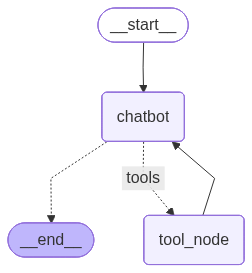

In [99]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)
# = create.agent

In [100]:
res = graph.invoke(
    {
        "messages":[("human", "안녕")]
    }
)

In [101]:
res

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='1fc7586d-5703-45ab-8d0a-4c0d742ab3ae'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 1517, 'total_tokens': 1531, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzcmfaFE8NcvIYoqpWPXum0HSOKoJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f459e-d697-7313-8187-9efa653123b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1517, 'output_tokens': 14, 'total_tokens': 1531, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'r

In [102]:
res2 = graph.invoke(
    {
        "messages":[("human", "AI의 최신 동향에 대해서 조사해서 설명해 주세요.")]
    }
)

In [103]:
res2["messages"]

[HumanMessage(content='AI의 최신 동향에 대해서 조사해서 설명해 주세요.', additional_kwargs={}, response_metadata={}, id='ba996635-63ec-4d41-8b0d-31850a013324'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 1523, 'total_tokens': 1579, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzcnC9hRI5pmvMhVrGZCgVNuCczQY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f459f-5743-7e52-9911-7e77c831d38c-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'AI latest trends 2026 state of AI 2026 major developments foundation models agents multimodal open weights', 'search_depth': 'advanced', 'topic': 'gener

In [104]:
print(res2["messages"][-1].content)

물론입니다. 2026년 7월 9일 기준으로 보면, **AI의 최신 동향은 “더 똑똑한 모델”보다 “더 오래 일하는 에이전트, 더 강한 멀티모달, 더 효율적인 오픈웨이트, 그리고 물리 세계로의 확장”** 쪽으로 뚜렷하게 움직이고 있습니다.

## 핵심 흐름 5가지

### 1) AI 에이전트가 주류로 가는 중
예전의 AI는 질문에 답하는 “대화형 모델”에 가까웠다면, 지금은 **도구를 쓰고, 계획을 세우고, 여러 단계를 수행하는 에이전트**가 중심입니다.  
즉, 단순 생성보다:
- 파일 읽기/쓰기
- 코드 수정
- 검색
- 일정/업무 자동화
- 장기 작업 관리

같은 실제 업무 수행 능력이 중요해졌습니다.

**왜 중요하냐면:**  
AI가 “말만 잘하는 도구”에서 “일을 대신 해주는 시스템”으로 바뀌고 있기 때문입니다.

---

### 2) 멀티모달이 기본이 됨
텍스트만 이해하는 AI는 점점 옛 방식이 되고 있습니다.  
최신 흐름은 **텍스트 + 이미지 + 음성 + 영상**을 함께 다루는 멀티모달 AI입니다.

최근에는 특히:
- 긴 영상 이해
- 이미지·영상 생성
- 여러 모달을 함께 쓰는 작업
- “한 입력으로 여러 출력”을 만드는 모델

이 강해지고 있습니다.

**의미:**  
앞으로 AI는 문장 생성기보다 **시각과 청각을 포함한 범용 인터페이스**에 더 가까워질 가능성이 큽니다.

---

### 3) 오픈웨이트 모델이 빠르게 강해짐
예전에는 최고 성능이 주로 폐쇄형 모델에 있었지만, 지금은 **오픈웨이트(open-weight) 모델도 상당히 경쟁력**을 갖고 있습니다.

특징은:
- 배포와 커스터마이징이 쉬움
- 기업 내부 도입이 쉬움
- 비용 효율이 좋음
- 특정 업무에 맞게 미세조정하기 좋음

검색 결과에서도 Kimi K2.5, GLM 계열 같은 오픈 모델들이 강한 agentic 성능을 보인다는 흐름이 보였습니다.

**정리:**  
“성능=폐쇄형” 공식이 약해지고, **오픈 모델 생태계가 본격 경쟁 구도**로 들어왔습니다.

---

#

In [105]:
res3 = graph.invoke({"messages": [("human", "러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.")]})

In [107]:
print(res3["messages"][-1].content)

물론입니다. 2026년 7월 9일 기준으로, **러시아-우크라이나 전쟁**과 **미국-이란 긴장/전쟁 상황**을 간단히 정리해드릴게요.

## 1) 러시아-우크라이나 전쟁 최신 상황
최근 흐름은 **러시아의 완만한 공세 지속 + 우크라이나의 드론/장거리 타격 강화**로 요약됩니다.

- **러시아군은 동부·남부 전선에서 계속 압박**을 이어가고 있습니다. 특히 포크로우스크, 슬로뱐스크-크라마토르스크, 쿠푼스크 방면이 주요 관심 지역입니다.
- 다만 최근 보도와 분석에 따르면, **러시아의 진격 속도는 둔화**되었거나 일부 지역에서는 되돌려지는 양상도 보입니다.
- **우크라이나는 후방 타격을 크게 강화**하고 있습니다.
  - 러시아 점령지와 러시아 본토의 **군수·정유·물류 인프라**를 드론과 장거리 무기로 공격하고 있고,
  - 이로 인해 **러시아 내 연료 부족**과 전선 물류 차질이 나타나고 있다는 분석이 나옵니다.
- ISW(전쟁연구소)와 Reuters 보도를 보면, 우크라이나는 최근 **장거리 타격 범위를 넓히고 강도도 높이는 중**입니다.
- 전반적으로는 **교착이지만 우크라이나의 비대칭 타격이 러시아의 전투 지속 능력을 약화시키는 방향**으로 보입니다.

## 2) 미국-이란 전쟁/충돌 최신 상황
이쪽은 **정규전이라기보다, 제한적 군사 충돌과 매우 불안정한 휴전/협상 상태**에 가깝습니다.

- 최근 보도에 따르면, **미국은 이란의 방공망과 발사 시설 등을 타격**했고,
- 이에 이란도 **미군 기지나 관련 목표물에 드론·미사일 공격**으로 대응했습니다.
- 하지만 대체로는 **전면전으로 확전되지 않도록 관리되는 긴장 상태**입니다.
- 최근 기사들에서는:
  - **호르무즈 해협 주변 긴장**
  - **미군과 이란 사이의 제한적 교전**
  - **협상 재개 가능성**
  - **아주 불안정한 휴전 유지**
  가 함께 언급됩니다.
- 특히 이란은 **군사 행동과 협상 가능성을 동시에 활용**하며, 미국의 추가 공격을 억제하려는 모습입니다

In [108]:
############ stream으로 조회
gen = graph.stream(
    {
        "messages": [("human", "러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.")]
    }
)
gen

<generator object Pregel.stream at 0x000002B5F31D0940>

In [109]:
for event in gen:
    print(event)
    print("-----------------------------------------")

{'chatbot': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 1534, 'total_tokens': 1643, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzcoltRIyNAoHa2EAi47RtzyFlXQQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f45a0-d0c5-7803-9b2a-c560c3ece1fe-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Russia Ukraine war latest situation 2026 July 9', 'search_depth': 'advanced', 'topic': 'news', 'time_range': 'month', 'include_images': False}, 'id': 'call_132TopntXBOMUyIFGF5VngGX', 'type': 'tool_call'}, {'name': 'tavily_search', 'args': {'query': 'US Iran conflict late

In [ ]:
gen = graph.stream(
    {
        "messages": [("human", "러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.")]
    },
    stream_mode="messages" # tuple[응답Chunk, metadata: 어떤 노드의 답인지]
)

for i, event in enumerate(gen):
    if event[1]["langgraph_node"]=="chatbot":
        print(event[0].content, end="")
    # print(event[0])
    # print(event[1])
    # if i == 0:
    #     break

물론이죠. **2026년 7월 9일 기준**으로 보면, 두 분쟁은 이렇게 정리할 수 있습니다.

## 1) 러시아-우크라이나 전쟁 최신 상황
- **러시아의 공습 강도는 여전히 매우 높습니다.** 7월 초 Reuters 보도에 따르면 러시아는 키이우에 대규모 야간 공습을 감행했고, 러시아 측은 **우크라이나에 대한 압박을 더 키우겠다고** 밝혔습니다.
- **드론·미사일 공격이 계속 확대**되고 있습니다. 우크라이나는 방공망으로 상당수를 요격하고 있지만, 일부는 도시와 기반시설에 타격을 주고 있습니다.
- **우크라이나는 러시아 후방 물류와 연료 인프라를 지속적으로 타격**하고 있습니다. ISW(전쟁연구소)와 Reuters 보도를 보면, 이 공격 때문에 **러시아 본토와 점령지 일부에서 휘발유 부족·배급 현상**이 나타나고 있습니다.
- 전선 전체로는 **큰 영토 변화보다 소모전 양상**이 이어지고 있으며, 러시아는 병력·미사일·드론 생산을 늘리는 쪽으로 대응 중입니다.

### 한줄 요약
**러시아의 공습 확대 vs 우크라이나의 후방 교란·방공 유지**가 핵심 흐름입니다.

---

## 2) 미국-이란 전쟁 최신 상황
- 6월 중순 이후 상황이 **완전한 전면전보다는 “휴전 이후의 불안정한 긴장 상태”**에 가깝습니다.
- 여러 보도에 따르면 미국과 이란은 **휴전/평화 합의 틀**에 들어갔지만,  
  - **호르무즈 해협 안전 문제**
  - **이란의 미사일/드론 관련 시설**
  - **핵 프로그램 후속 협상**
  이 아직 완전히 정리되지 않았습니다.
- 7월 8일 기준 Jerusalem Post/Reuters 보도에서는 **호르무즈 해협에서 선박 공격이 있었고, 미국이 이란의 방공·발사 시설을 타격했다**는 내용이 나왔습니다. 즉, **휴전 상태라도 국지적 충돌과 보복 가능성은 남아 있습니다.**
- 또한 국제사회는 **중동 해상로 안전**과 **추가 확전 방지**에 집중하고 있습니다.

### 한줄 요약
**전면전은 일단 멈췄지만, 호르무즈 해

In [112]:
graph.invoke({
    "messages":[("human", "내가 아까한 질문에 대해 좀 더 자세히 알려줘.")]
})

{'messages': [HumanMessage(content='내가 아까한 질문에 대해 좀 더 자세히 알려줘.', additional_kwargs={}, response_metadata={}, id='88092429-5bf3-4b75-9e96-c4e8a3d390d5'),
  AIMessage(content='물론이죠. 다만 지금 대화만으로는 **“아까 한 질문”의 내용이 확인되지 않아서** 정확히 어떤 주제를 더 자세히 설명드려야 하는지 알기 어렵습니다.\n\n가능하면 아래 중 하나로 다시 보내주세요:\n- **아까 질문을 그대로 복사해서** 보내기\n- **주제만 짧게** 적기\n- 제가 이미 답한 내용 중 **어느 부분을 더 알고 싶은지** 말하기\n\n예를 들면:\n- “아까 말한 **환율 변동**에 대해 더 설명해줘”\n- “**그 방법의 장단점**을 자세히 알려줘”\n- “**예시까지 포함해서** 다시 설명해줘”\n\n질문을 다시 주시면 바로 자세히 풀어서 설명해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 178, 'prompt_tokens': 1529, 'total_tokens': 1707, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzdBgPzNXAwegOufNcCz3bTKoGN9V', 'se